In [1]:
import pandas as pd
import numpy as np


In [2]:
df =pd.read_csv('data/02_telco_cleaned.csv')

# **Descriptive Statistics**

## **1. Overview of Dataset**

In [3]:
print("=== 1. DATASET SHAPE ===")
print(f"Total Rows (Customers): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

=== 1. DATASET SHAPE ===
Total Rows (Customers): 7032
Total Columns (Features): 20



In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

<small>The dataset contains 20 columns covering demographic data, subscribed services, account details, and charges.

**Demographics:** gender, SeniorCitizen, Partner, Dependents

**Services:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

**Account Info:** tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

**Target Variable:** Churn (Yes/No)


#### **Analysing the Target Variable (Churn)**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

=== TARGET VARIABLE ANALYSIS ===
Raw Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64




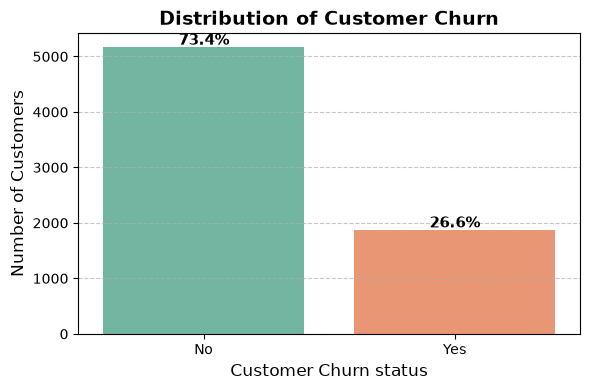

In [7]:
print("=== TARGET VARIABLE ANALYSIS ===")

# -------------------------------------------------------------
# 1. Calculating the Exact Counts and Percentages
# -------------------------------------------------------------
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Raw Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_percentages.round(2))
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------
# 2. I chose to visualise the Distribution (Count Plot)
# -------------------------------------------------------------
plt.figure(figsize=(6, 4))
# Creating a clean bar chart of Churn vs No Churn
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)

# Styling the plot
plt.title('Distribution of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the percentage labels on top of the bars
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    plt.gca().annotate(percentage, (x, y), fontsize=11, fontweight='bold')

plt.tight_layout()

plt.savefig('plots/01_churn_distribution.png', bbox_inches='tight', dpi=300)

plt.show()

<small> Our data shows us that approximately **73% of the customers stay** and **27% churn**.</small>


**Modeling Note for later stages:** <small> >>> Our data is imbalance (~73% No / ~27% Yes). This means accuracy will be a trap metric. > Hence, if a  model guesses "No" for every single customer, it would instantly be 73.5% accurate, but it would catch zero of the customers who are actually leaving—making it totally useless to the business.

Therefore, during modeling, we must focus on:

Recall: To ensure we catch as many of the actual churners as possible (this minises False Negatives).

F1-Score: To find a healthy balance between Precision and Recall.

Resampling: We might need to look into techniques like SMOTE (oversampling the minority class) or adjusting class weights when training the model.

## **2. Numerical Features Analysis**

<small>We have three main continuous numerical variables: **tenure, MonthlyCharges, and TotalCharges**.


The goal in this section is to understand the shapes and distributions of our continuous variables and see exactly how they relate to whether a customer churns or stays.

To do this cleanly, I will use histograms with a kernel density estimate (KDE) overlay split by the target variable (Churn).

##### **a) Histograms**

===NUMERIC FEATURES ANALYSIS ===


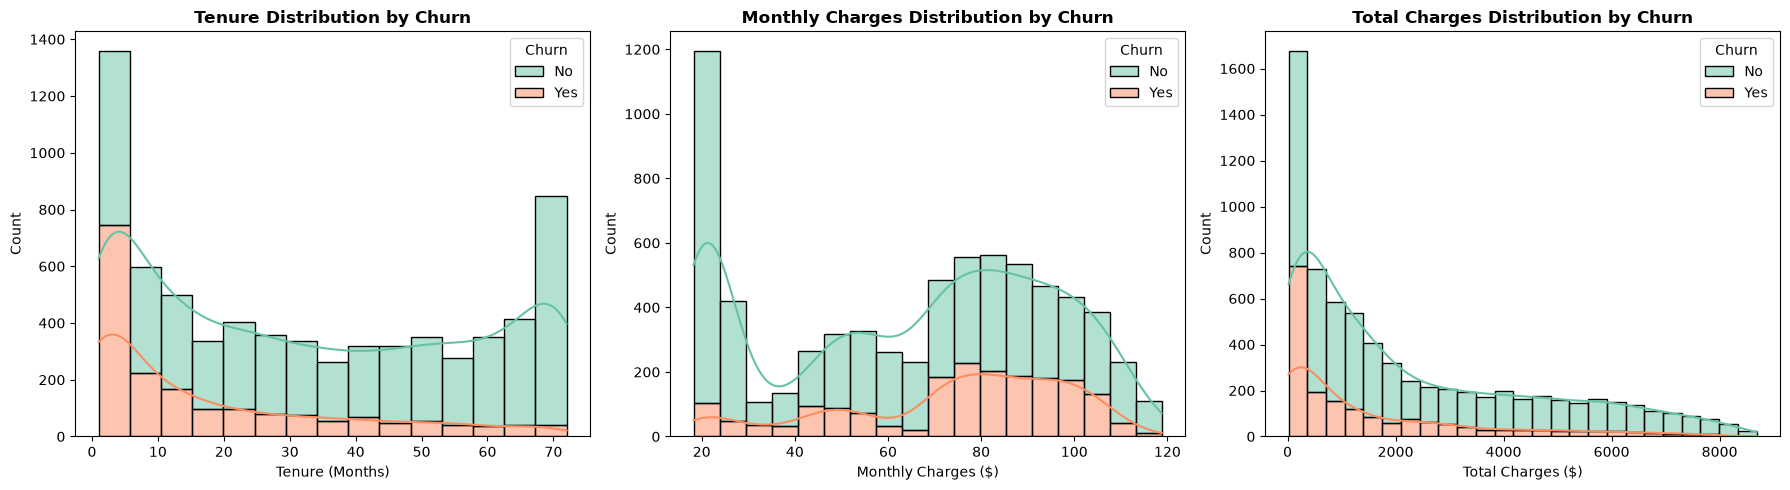

In [8]:
print("===NUMERIC FEATURES ANALYSIS ===")

# Here I am setting up a grid of 3 plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tenure Distribution
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')

# 2. Monthly Charges Distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')

# 3. Total Charges Distribution
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[2])
axes[2].set_title('Total Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()

plt.savefig('plots/02_numeric_feature_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

**Tenure:**

<small> **X-Axis (Horizontal):** Represents Tenure, which is the continuous time variable measured in months (ranging from 1 to 72 months). It displays how long the customer has been with the company. 

**Y-Axis (Vertical):** Represents the Count (frequency) of customers. 

We see a huge spike in the number of customers churning at 0-3 months. Thereafter, there is a sharp decline in the graph until 20 months, but the graph continues to decrease, but at a steadier rate. 

At around 70+ months, we see the graph had dropped signigicantly indicating the highly loyal, long-tern customers.

**Churn Relationship:** As tenure increases, the probability of churn drops significantly.

**Monthly Charges:**

<small>This distribution shows a  spike around \$20, the cheap end. There is a huge spike of users there with fewer churning. This represents low-risk users (likely basic phone-only plans).

 The rate of churning increases significantly from \$70 to \$100 range with around 200 customers leaving the services. High prices clearly frustrate users or drive them to seek competitor deals.

**Churn Relationship:** Higher monthly charges generally correlate with a higher likelihood of churn.

**TotalCharges:**

<small>The graph is heavily skewed to the left because most customers have lower total payments, while a few long-term customers accumulate high totals.

##### **b) Correlation Analysis**

=== CORRELATION MATRIX ===


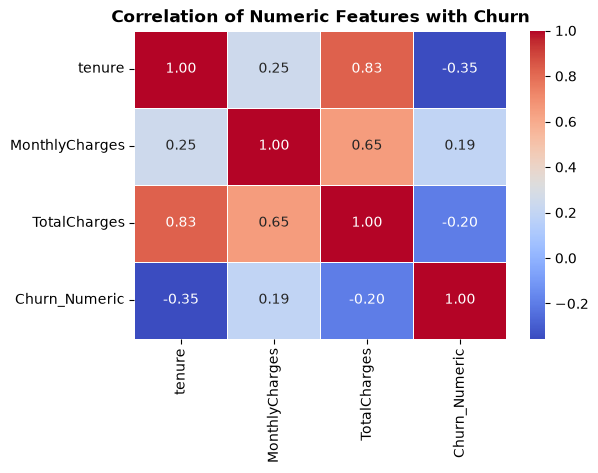

In [9]:
# -------------------------------------------------------------
# Correlation Matrix (To see how numbers relate to each other)
# -------------------------------------------------------------
print("=== CORRELATION MATRIX ===")
# Convert Churn to 1/0 just for the correlation check
df_numeric_check = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_numeric_check['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(6, 4))
sns.heatmap(df_numeric_check.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation of Numeric Features with Churn', fontsize=12, fontweight='bold')

plt.savefig('plots/03_correlation_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

<small> **Modelling note:** >>>From the Correlation Matrix, we can see that the orrelation between tenure and TotalCharges is 0.83 which is quite high. This is a multicollinearity relationship which will confuse some algorithms. So the column TotalCharl may need to be dropped, but the tenure and MonthlyCharges can be kept.

## **3. Categorical Features Analysis**

I have categorical data (text labels) and with target outcome (Churn: Yes/No). I need a statistical graphic that helps me to see which categories have the highest volume of customers, and within those categories, what proportion are leaving?

### **a) Contract, InternetService, PaymentMethod and OnlineSecurity**

<small>In this section, I will be plotting bar charts for the categories: Contract, InternetService, PaymentMethod and OnlineSecurity as I am curious as to their churn proportions. Thereafter, will provide description of the charts </small>

##### **i) Bar Charts**

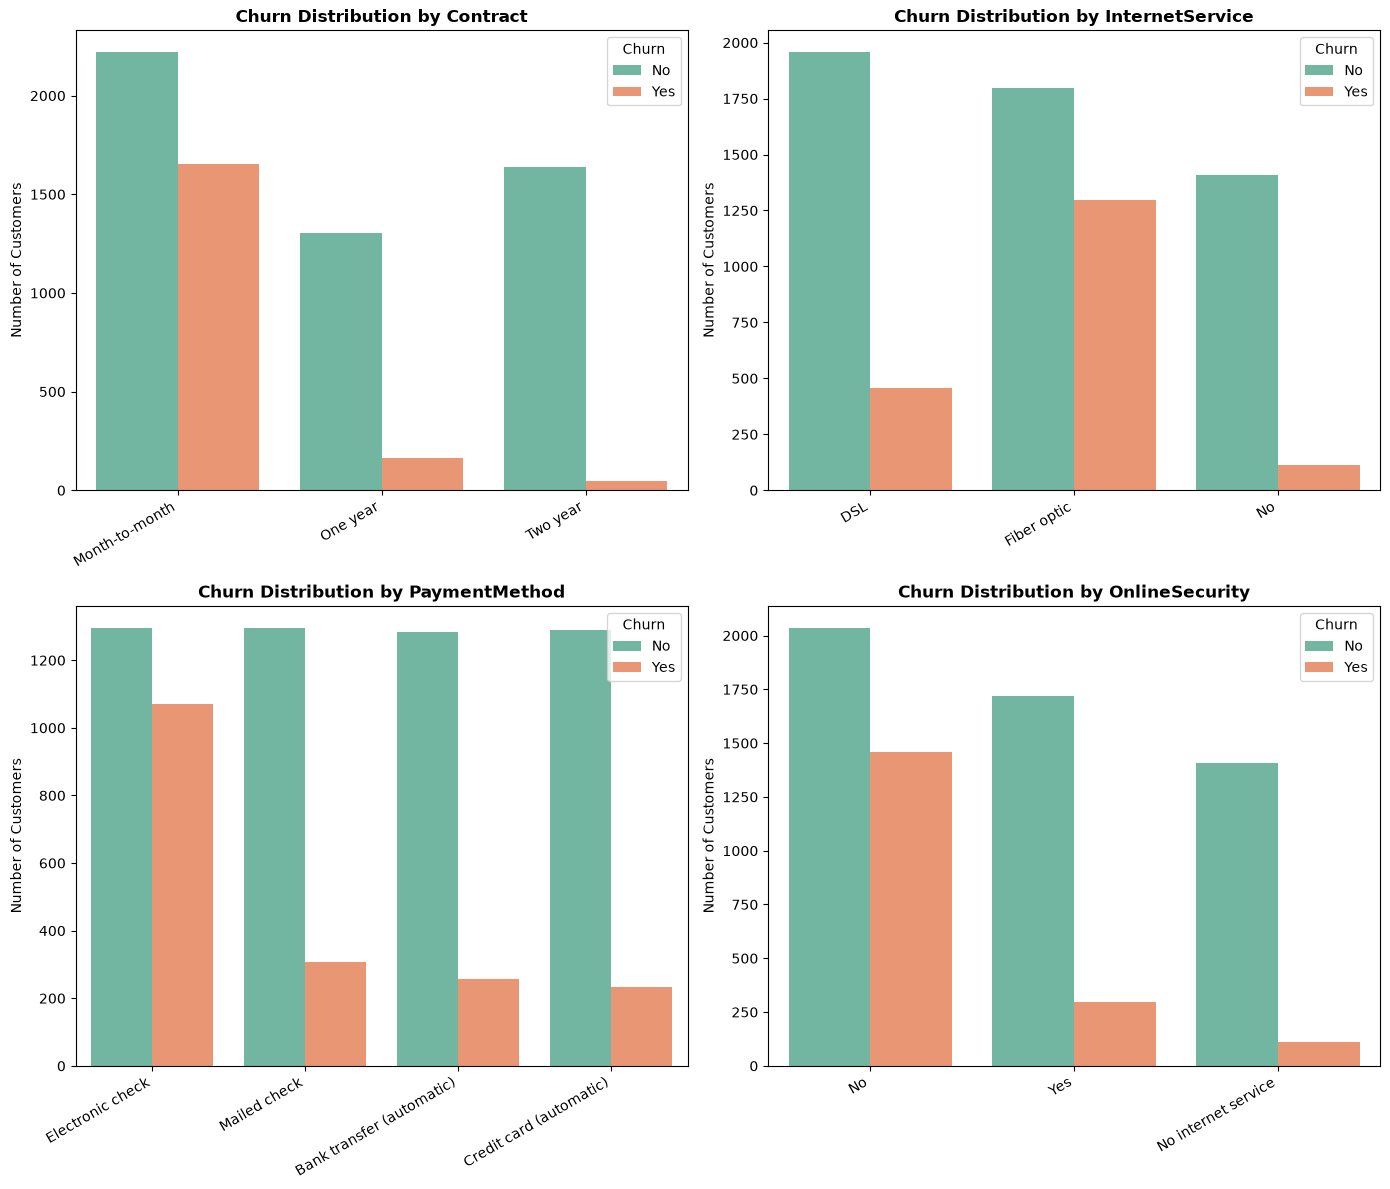

In [10]:


# Here are the categorical features I want to visualise first: Contract, InternetService, PaymentMethod, OnlineSecurity
features_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

# Setting up the grid dimensions dynamically
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Looping through features and build the plots
for i, col in enumerate(features_to_plot):
    # Create the countplot with Churn as the color breakdown
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    
    #Clean up aesthetics
    axes[i].set_title(f'Churn Distribution by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Remove redundant x-axis label
    axes[i].set_ylabel('Number of Customers')
    
    # Rotate long text labels so they don't overlap
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

# Adjustment of layout and display
plt.tight_layout()

plt.savefig('plots/04_categorical_feature_analysis.png', bbox_inches='tight', dpi=300)

plt.show()

##### **ii) Bar Charts Description**

<small> At first glance, Contract and Internet Service appear to be the largest contributors to customer attrition. 

**Churn Distribution by Contract:** This chart is a grouped bar chart comparing the number  of active and lost customers across three specific contracts: Month-to-month, One year, and Two year.The chart displays that the longer the contract, the less likely a customer is to churn.

The X-Axis (Categories): Represents the duration of the agreement a customer signed up for.

The Y-Axis (Volume): Shows the count of customers falling into those categories.


From the chart, we can see that Month-to-month accounts represent both the largest population of customers, but is then also our primary source of attrition. Because these customers have no strict structure or financial penalties for so they are not committed and are easily attracted by competitor's offers.

**Churn Distribution by PaymentMethod:** Fibre Optic is the largest contributor for Customer Churning. 


**Churn Distribution by PaymentMethod:** We see that the largest number of customers who churn are those who pay by Electronic Check. This could be due to the user re-evaluating their bill monthly as it's not an automated payment method.




**Churn Distribution by Online Security:** We see customers with the Online Security churned less than those without. This feature perhaps makes customers feel safe and therefore are more likely to stay with the company. </small>





### **b) Gender, TechSupport, StreamingTV and StreamingMovies**

<small>In this section, I will be looking  at the demographic category Gender followed by the feature TechSupport and finally entertainment subscriptions which are StreamingTV and StreamingMovies

##### **i) Bar Charts**

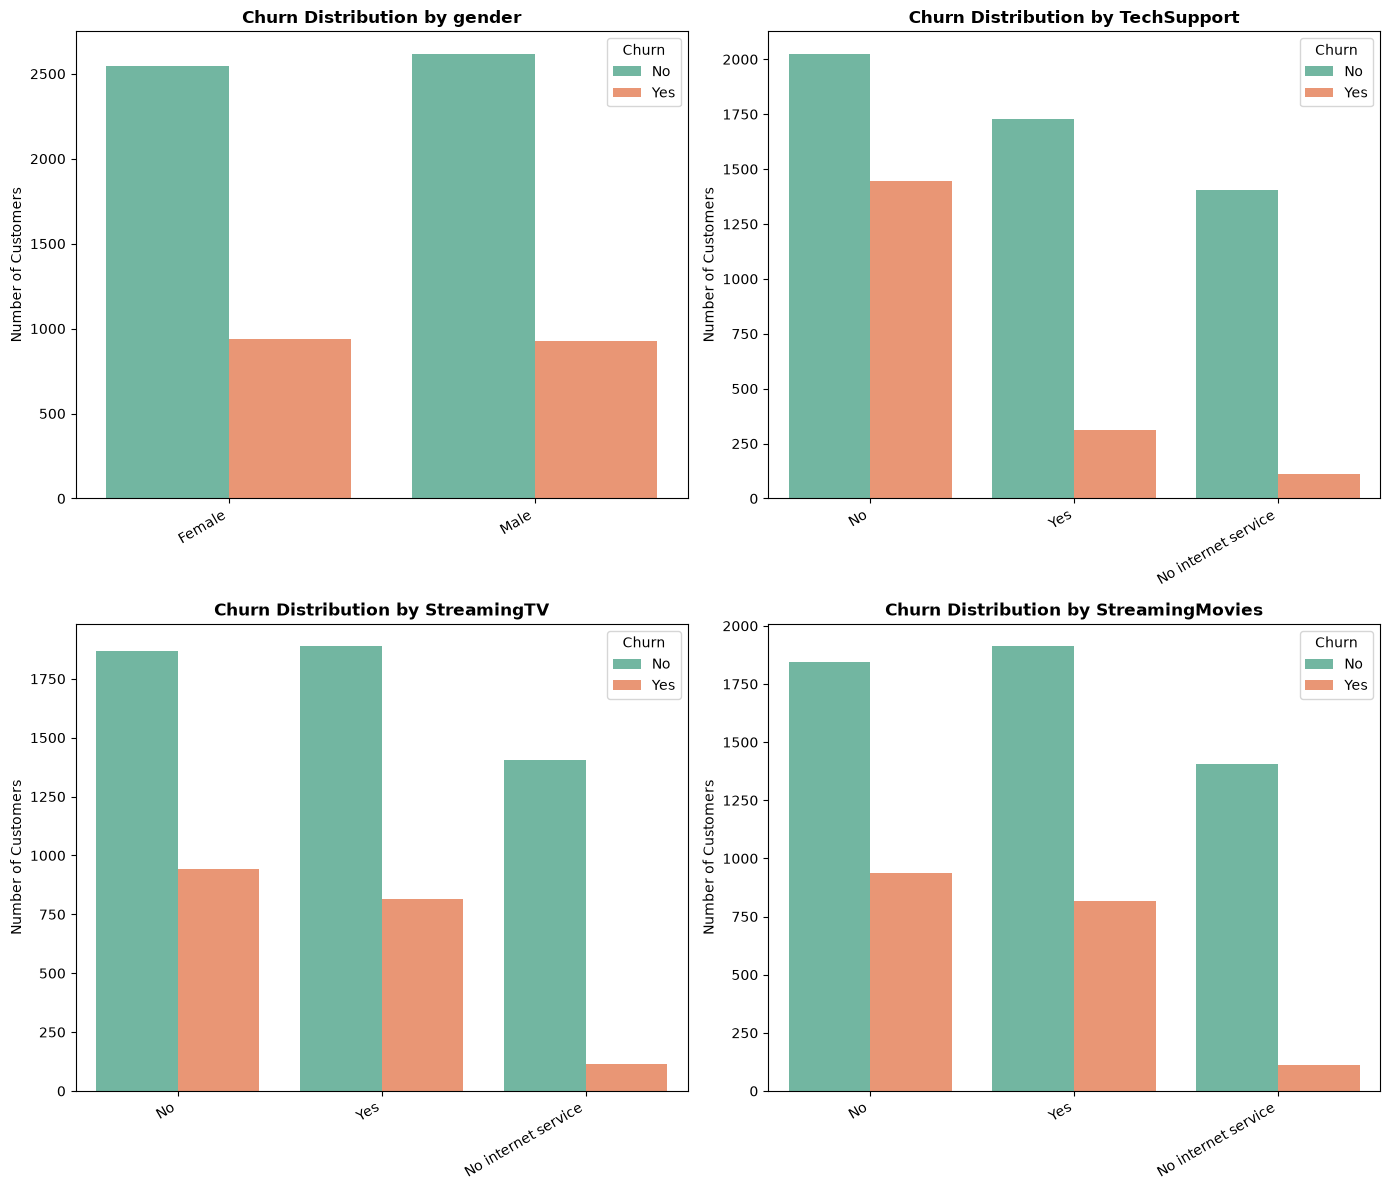

In [11]:


#  In this section, I want to look at more categorical features which are gender, TechSupport, StreamingTV, StreamingMovies
features_to_plot = ['gender', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Step 2: Setting up the grid dimensions dynamically (2x2 grid covers 4 features perfectly)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten() 

# Step 3: Looping through features and build the plots
for i, col in enumerate(features_to_plot):
    # Create the countplot with Churn as the color breakdown
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    
    # Clean up aesthetics
    axes[i].set_title(f'Churn Distribution by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Remove redundant x-axis label
    axes[i].set_ylabel('Number of Customers')
    
   
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

# Step 4: Adjustment of layout and display
plt.tight_layout()

plt.savefig('plots/05_categorical_feature_analysis.png', bbox_inches='tight', dpi=300)

plt.show()

##### **ii) Bar Charts Description**

<small>**Churn Distribution by gender:** 
We can see that the number of male and female customers churning is almost the same. The bars are the same level for male and female customers.


**Churn Distribution by TechSupport:** The chart displays that customers who receive tech support churn less than those without. It would be good to offer this to customers to improve their likelihood of staying with the company.

**Churn Distribution by StreamingTV/Movies:** Looking at the bars on the Yes (subscribed to streaming services) and No (not subscribed to streaming services), it appears customers with a streaming service(movies and TV) and those without churn in almost similar proportion. It therefore shows inclusion of the streaming services makes no difference to improving the customer's loyalty. 

### **c) Improving Customer Loyalty**

<small> From the bar charts explored above, it was identified that the features OnlineSecurity and TechSupport have much lower numbers of customers who were churning. On the other hand, streaming services were a larger contributor to customer attrition.

In this section I will be comparing the proportions in percentages of these add-on categories.

##### **i) Proportion of Customers subscribed to add-on Features**

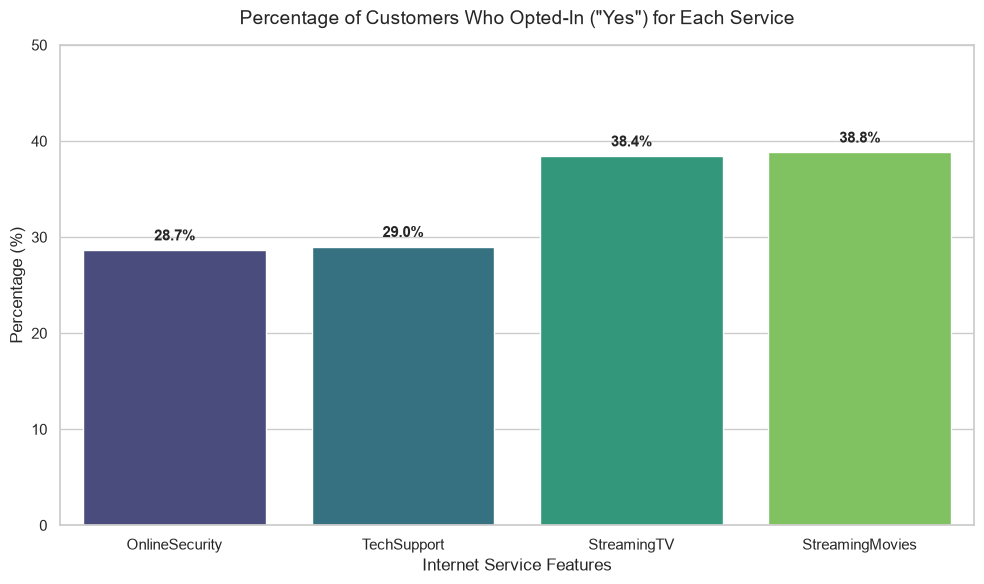

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# I want to show the percentage of "Yes" for each service out of the entire dataset.
# Creating a bar chart to show the % of 'Yes'
yes_percentages = {}
for col in cols:
    pct_yes = (df[col] == 'Yes').mean() * 100
    yes_percentages[col] = pct_yes

# Convert to dataframe for plotting
plot_df = pd.DataFrame(list(yes_percentages.items()), columns=['Service', 'Opt-In Percentage'])

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Service', y='Opt-In Percentage', data=plot_df, palette='viridis', hue='Service', legend=False)

plt.title('Percentage of Customers Who Opted-In ("Yes") for Each Service', fontsize=14, pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Internet Service Features', fontsize=12)
plt.ylim(0, 50)

# Adding percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()

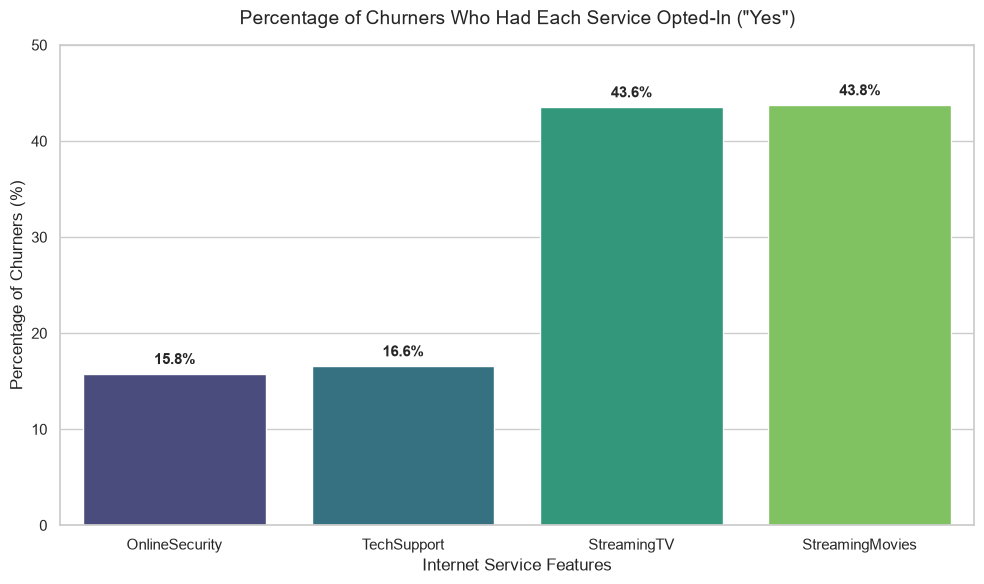

In [13]:

cols = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies']
churners = df[df['Churn'] == 'Yes']

# 2. Calculate percentages of churners who had each service
churner_percentages = {}
for col in cols:
    pct_yes = (churners[col] == 'Yes').mean() * 100
    churner_percentages[col] = pct_yes

# 3. Construct the DataFrame
plot_df = pd.DataFrame(list(churner_percentages.items()), columns=['Service', 'Churner Opt-In Percentage'])

# 4. Plot with fixed hue and legend parameters to remove the warning
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Service', y='Churner Opt-In Percentage', data=plot_df, palette='viridis',hue='Service',legend=False)

plt.title('Percentage of Churners Who Had Each Service Opted-In ("Yes")', fontsize=14, pad=15)
plt.ylabel('Percentage of Churners (%)', fontsize=12)
plt.xlabel('Internet Service Features', fontsize=12)
plt.ylim(0, 50)

# Add percentage labels cleanly on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()

In [14]:
# -------------------------------------------------------------
# Streaming Services Subscriptions Analysis
# -------------------------------------------------------------
print("=== STREAMING SERVICES ANALYSIS ===")

# Total number of customers in the dataset
total_customers = len(df)

# 1. Count exact subscriptions
tv_subscribers = (df['StreamingTV'] == 'Yes').sum()
movie_subscribers = (df['StreamingMovies'] == 'Yes').sum()

# 2. Count customers subscribed to AT LEAST ONE streaming service (TV or Movies)
any_streaming_subscribers = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).sum()

# 3. Calculate the averages (percentages)
tv_avg_pct = (tv_subscribers / total_customers) * 100
movie_avg_pct = (movie_subscribers / total_customers) * 100
any_streaming_avg_pct = (any_streaming_subscribers / total_customers) * 100

# Print the final insights
print(f"Total Base Customers: {total_customers}")
print(f"Streaming TV Subscribers: {tv_subscribers} ({tv_avg_pct:.2f}%)")
print(f"Streaming Movies Subscribers: {movie_subscribers} ({movie_avg_pct:.2f}%)")
print(f"Subscribed to at least one Streaming Service: {any_streaming_subscribers} ({any_streaming_avg_pct:.2f}%)")

=== STREAMING SERVICES ANALYSIS ===
Total Base Customers: 7032
Streaming TV Subscribers: 2703 (38.44%)
Streaming Movies Subscribers: 2731 (38.84%)
Subscribed to at least one Streaming Service: 3495 (49.70%)


In [15]:
# -------------------------------------------------------------
# Security & Technical Support Services Analysis
# -------------------------------------------------------------
print("=== SECURITY & TECH SUPPORT ANALYSIS ===")

# Total number of customers in the dataset
total_customers = len(df)

# 1. Count exact subscriptions
security_subscribers = (df['OnlineSecurity'] == 'Yes').sum()
support_subscribers = (df['TechSupport'] == 'Yes').sum()

# 2. Count customers subscribed to AT LEAST ONE utility service (Security or Tech Support)
any_utility_subscribers = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).sum()

# 3. Calculate the averages (percentages)
security_avg_pct = (security_subscribers / total_customers) * 100
support_avg_pct = (support_subscribers / total_customers) * 100
any_utility_avg_pct = (any_utility_subscribers / total_customers) * 100

# Print the final insights
print(f"Total Base Customers: {total_customers}")
print(f"Online Security Subscribers: {security_subscribers} ({security_avg_pct:.2f}%)")
print(f"Tech Support Subscribers: {support_subscribers} ({support_avg_pct:.2f}%)")
print(f"Subscribed to at least one Utility Service: {any_utility_subscribers} ({any_utility_avg_pct:.2f}%)")

=== SECURITY & TECH SUPPORT ANALYSIS ===
Total Base Customers: 7032
Online Security Subscribers: 2015 (28.65%)
Tech Support Subscribers: 2040 (29.01%)
Subscribed to at least one Utility Service: 2959 (42.08%)


In [16]:


# Calculate the flags again
has_streaming = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes'))
has_utility = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes'))

# Percentages
pct_streaming = has_streaming.mean() * 100
pct_utility = has_utility.mean() * 100

print(f"Streaming: {pct_streaming:.2f}%, Utility: {pct_utility:.2f}%")

# Plotting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

categories = ['At Least One\nStreaming Service\n(TV or Movies)', 'At Least One\nUtility Service\n(Security or Support)']
percentages = [pct_streaming, pct_utility]

ax = sns.barplot(x=categories, y=percentages, palette='Set2', hue=categories, legend=False)

plt.title('Service Bundling & Penetration Rates', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Customers (%)', fontsize=12)
plt.ylim(0, 100) # Since it's percentage, let's keep the scale consistent up to 100%

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height + 2),
                ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.close()
print("Saved visualization successfully.")

Streaming: 49.70%, Utility: 42.08%
Saved visualization successfully.


<small> There is a larger proportion of customers opting in for Streaming Services (~38%) as compared to the customer service features (OnlineSecurity and TechSupport) which are at (~29%). There difference between these features is around 10%. 



In [17]:
# -------------------------------------------------------------
# Summary Statistics for Numerical Features (Streamlined)
# -------------------------------------------------------------
print("=== NUMERICAL DISTRIBUTION ANALYSIS ===")

# Selecting only true continuous numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Calculating Summary Statistics (Generates mean, std, min, max, percentiles)
summary_stats = df[numerical_features].describe().T

# Renaming the 50% percentile to 'median' for better business context
summary_stats.rename(columns={'50%': 'median'}, inplace=True)

# Adding the Mode (most frequent value)
summary_stats['mode'] = df[numerical_features].mode().iloc[0]

# Displaying exactly what is requested: Mean, Median, Mode, Std Dev, Min, and Max
summary_stats = summary_stats[['mean', 'median', 'mode', 'std', 'min', 'max']]

# Displaying the clean DataFrame rounded to 2 decimal places
print(summary_stats.round(2))

=== NUMERICAL DISTRIBUTION ANALYSIS ===
                   mean   median   mode      std    min      max
tenure            32.42    29.00   1.00    24.55   1.00    72.00
MonthlyCharges    64.80    70.35  20.05    30.09  18.25   118.75
TotalCharges    2283.30  1397.48  20.20  2266.77  18.80  8684.80
